# Stochastic predator-prey model: lions and antelopes

Monthly simulation over 100 years with Poisson births and Binomial survival. See the README for the model description.

## 1. Variables Initialization


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

np.random.seed(42)  # fixed seed so the run (and the README figures) can be reproduced

prey_reproduction_rate = 1/12
predator_reproduction_rate = 1/24
predation_rate = 3
k=5

preys_carrying_capacity = 2000
predator_carrying_capacity = 50

initial_prey = 1500
initial_predators = 30

time_steps = 12*100
epsilon = 1e-4

## 2. Simulation

In [2]:
def simulate(initial_prey, initial_predators, time_steps):
    prey_population_history = [initial_prey]
    predator_population_history = [initial_predators]
    for t in range(time_steps):
        prey_population = prey_population_history[-1]
        predator_population = predator_population_history[-1]

        prey_births = np.random.poisson(prey_reproduction_rate * prey_population * max(1 - prey_population / preys_carrying_capacity, 0))

        p_hunted = (predation_rate * predator_population / (prey_population + epsilon)) * (prey_population / preys_carrying_capacity) ** 0.5 * max(1 - predator_population / predator_carrying_capacity, 0) ** 0.5


        prey_consumed = np.random.binomial(prey_population, min(p_hunted, 1))
        prey_surviving = prey_population - prey_consumed

        predator_survival_prob = np.exp(-(predator_population / (prey_consumed + epsilon)) ** 3 / k)

        predator_surviving = np.random.binomial(predator_population, predator_survival_prob)
        predator_births = np.random.poisson(predator_reproduction_rate * predator_population)

        new_predators = max(predator_surviving + predator_births, 0)
        new_prey = max(prey_surviving + prey_births, 0)

        prey_population_history.append(new_prey)
        predator_population_history.append(new_predators)
    return prey_population_history, predator_population_history

prey_population_history, predator_population_history = simulate(initial_prey, initial_predators, time_steps)


## 3. Visualization

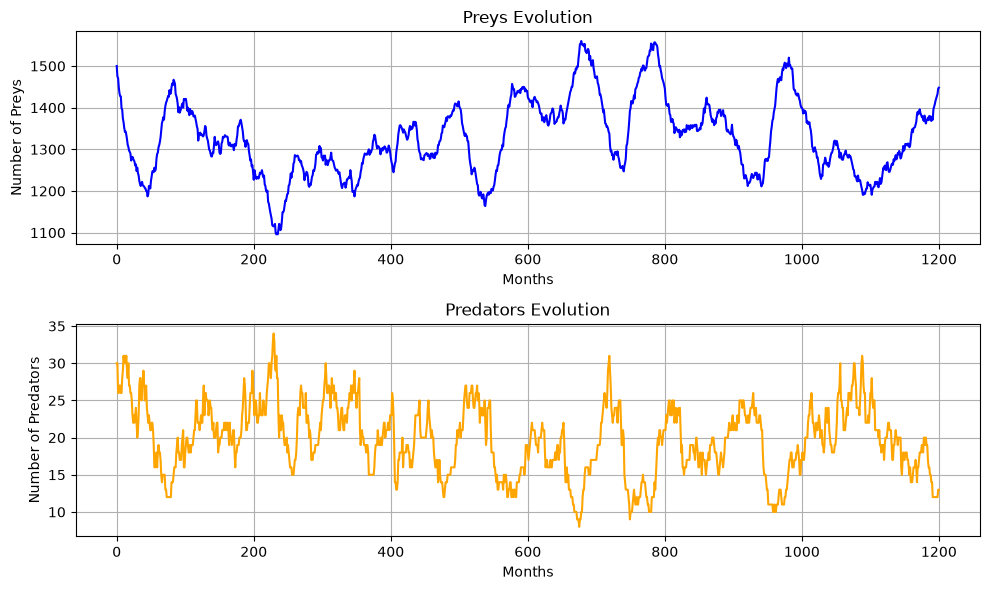

In [3]:
time = np.arange(time_steps+1)
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(time, prey_population_history, label="Preys", color="blue")
plt.xlabel("Months")
plt.ylabel("Number of Preys")
plt.title("Preys Evolution")
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(time, predator_population_history, label="Predators", color="orange")
plt.xlabel("Months")
plt.ylabel("Number of Predators")
plt.title("Predators Evolution")
plt.grid()

plt.tight_layout()
plt.savefig("figures/populations.png", bbox_inches="tight")
plt.show()

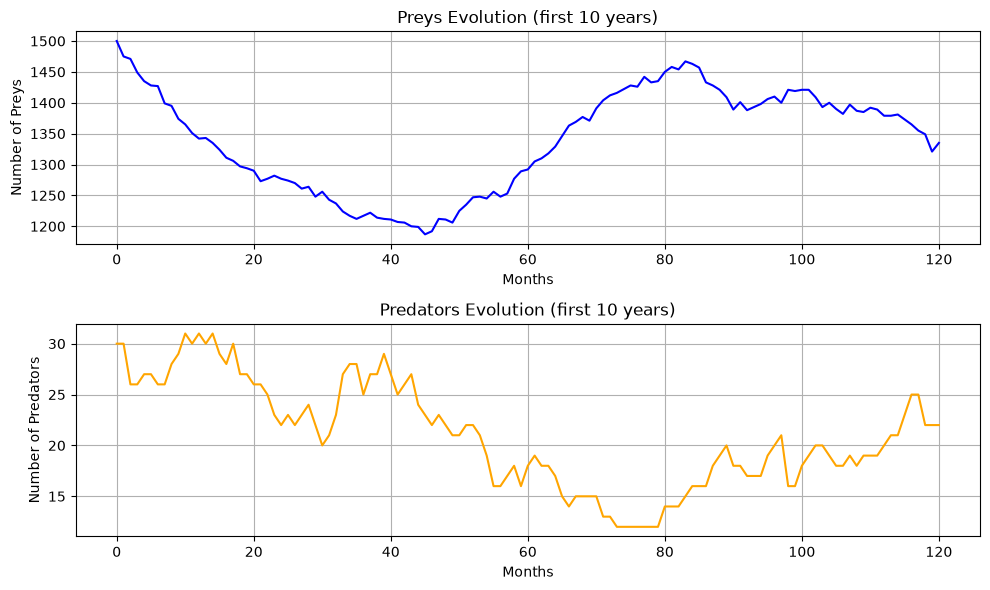

In [4]:
# First 10 years of the same run, where a single cycle is easier to see
zoom = 12 * 10
fig, (ax_prey, ax_pred) = plt.subplots(2, 1, figsize=(10, 6))

ax_prey.plot(time[:zoom + 1], prey_population_history[:zoom + 1], color="blue")
ax_prey.set_xlabel("Months")
ax_prey.set_ylabel("Number of Preys")
ax_prey.set_title("Preys Evolution (first 10 years)")
ax_prey.grid()

ax_pred.plot(time[:zoom + 1], predator_population_history[:zoom + 1], color="orange")
ax_pred.set_xlabel("Months")
ax_pred.set_ylabel("Number of Predators")
ax_pred.set_title("Predators Evolution (first 10 years)")
ax_pred.grid()

plt.tight_layout()
plt.savefig("figures/populations_10_years.png", bbox_inches="tight")
plt.show()


## 4. Stats

In [5]:
def calculate_population_stats(population_history):
    min_val = np.min(population_history)
    max_val = np.max(population_history)
    mean_val = np.mean(population_history)
    std = np.std(population_history)
    time_above_mean = np.sum(population_history > mean_val)
    time_below_mean = len(population_history) - time_above_mean

    return {
        "min": min_val,
        "max": max_val,
        "mean": mean_val,
        "std": std,
        "time_above_mean": time_above_mean,
        "time_below_mean": time_below_mean
    }

prey_stats = calculate_population_stats(prey_population_history)
predator_stats = calculate_population_stats(predator_population_history)

print("Prey Stats:", prey_stats)
print("Predator Stats:", predator_stats)

Prey Stats: {'min': np.int64(1096), 'max': np.int64(1560), 'mean': np.float64(1328.1790174854289), 'std': np.float64(90.1195270279463), 'time_above_mean': np.int64(576), 'time_below_mean': np.int64(625)}
Predator Stats: {'min': np.int64(8), 'max': np.int64(34), 'mean': np.float64(19.74104912572856), 'std': np.float64(4.721773248781355), 'time_above_mean': np.int64(629), 'time_below_mean': np.int64(572)}


## 5. Animation

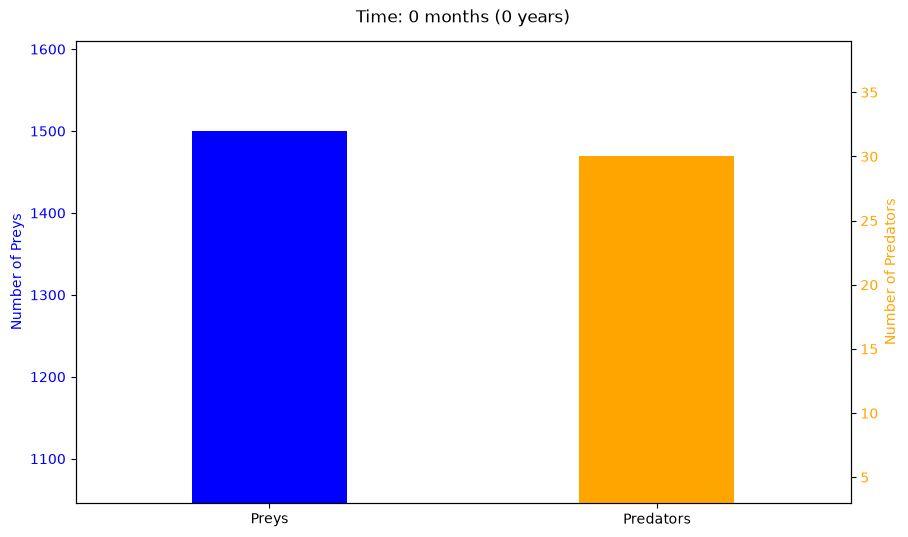

In [6]:
prey_min, prey_max = prey_stats['min'] - 50, prey_stats['max'] + 50
predator_min, predator_max = predator_stats['min'] - 5, predator_stats['max'] + 5

time_steps = len(prey_population_history) - 1
width = 0.4

fig, ax = plt.subplots(figsize=(10, 6))

prey = ax.bar(0, prey_population_history[0], width, color="blue", label="Preys")
ax.set_ylabel("Number of Preys", color="blue")
ax.tick_params(axis="y", labelcolor="blue")
ax.set_ylim(prey_min, prey_max)

ax2 = ax.twinx()
predator = ax2.bar(1, predator_population_history[0], width, color="orange", label="Predators")
ax2.set_ylabel("Number of Predators", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")
ax2.set_ylim(predator_min, predator_max)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Preys", "Predators"])
ax.set_xlim(-0.5, 1.5)

time_text = ax.text(0.5, 1.05, "", ha="center", va="center", fontsize=12, transform=ax.transAxes)

def update(frame):
    prey[0].set_height(prey_population_history[frame])
    predator[0].set_height(predator_population_history[frame])

    months = frame
    years = months // 12
    time_text.set_text(f"Time: {months} months ({years} years)")

    return [prey[0], predator[0], time_text]

ani = FuncAnimation(fig, update, frames=time_steps + 1, interval=50, blit=False)
ani.save("figures/population_bars.gif", writer="pillow", fps=20, dpi=45)


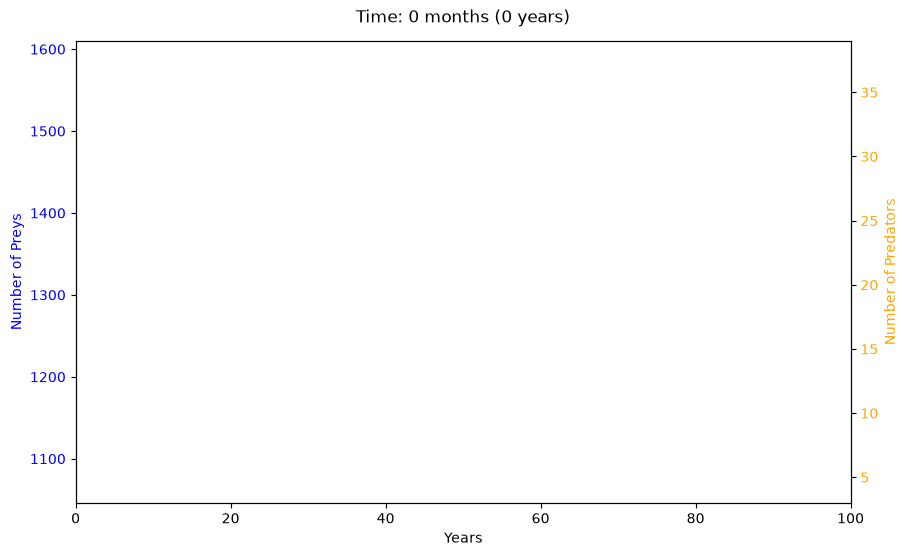

In [7]:
# Same run as a line chart, with the same frames and speed as the bar animation
fig, ax = plt.subplots(figsize=(10, 6))
years = np.arange(time_steps + 1) / 12

prey_line, = ax.plot([], [], color="blue")
ax.set_xlim(0, time_steps / 12)
ax.set_ylim(prey_min, prey_max)
ax.set_xlabel("Years")
ax.set_ylabel("Number of Preys", color="blue")
ax.tick_params(axis="y", labelcolor="blue")

ax2 = ax.twinx()
predator_line, = ax2.plot([], [], color="orange")
ax2.set_ylim(predator_min, predator_max)
ax2.set_ylabel("Number of Predators", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

lines_text = ax.text(0.5, 1.05, "", ha="center", va="center", fontsize=12, transform=ax.transAxes)

def update_lines(frame):
    prey_line.set_data(years[:frame + 1], prey_population_history[:frame + 1])
    predator_line.set_data(years[:frame + 1], predator_population_history[:frame + 1])
    lines_text.set_text(f"Time: {frame} months ({frame // 12} years)")
    return [prey_line, predator_line, lines_text]

ani_lines = FuncAnimation(fig, update_lines, frames=time_steps + 1, interval=50, blit=False)
ani_lines.save("figures/population_lines.gif", writer="pillow", fps=20, dpi=45)


## 6. Limit cases

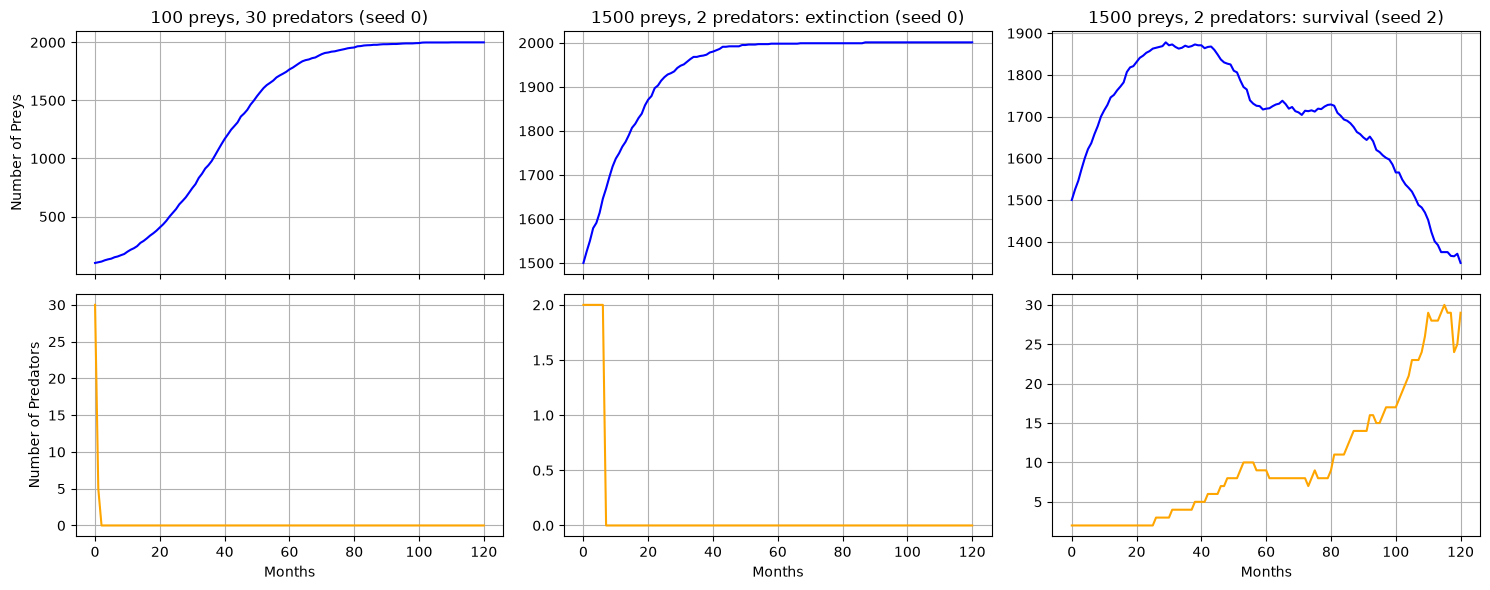

In [8]:
# Limit cases over 10 years. With 2 lions the outcome depends on chance,
# so for each case we take the first seed that gives the outcome we want to show.
limit_steps = 12 * 10

def first_seed(initial_prey, initial_predators, predators_survive):
    for seed in range(1000):
        np.random.seed(seed)
        prey, predators = simulate(initial_prey, initial_predators, limit_steps)
        if (predators[-1] > 0) == predators_survive:
            return seed, prey, predators

cases = [
    ("100 preys, 30 predators", *first_seed(100, 30, predators_survive=False)),
    ("1500 preys, 2 predators: extinction", *first_seed(1500, 2, predators_survive=False)),
    ("1500 preys, 2 predators: survival", *first_seed(1500, 2, predators_survive=True)),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
for col, (title, seed, prey, predators) in enumerate(cases):
    axes[0, col].plot(prey, color="blue")
    axes[0, col].set_title(f"{title} (seed {seed})")
    axes[1, col].plot(predators, color="orange")
    axes[1, col].set_xlabel("Months")
    for ax in axes[:, col]:
        ax.grid()
axes[0, 0].set_ylabel("Number of Preys")
axes[1, 0].set_ylabel("Number of Predators")

plt.tight_layout()
plt.savefig("figures/limit_cases.png", bbox_inches="tight")
plt.show()
